In [ ]:
import matplotlib.pyplot as plt
from pyclustree import clustree
import scanpy as sc
import anndata as ad
import pandas as pd
import scimap as sm
import seaborn as sns
import re
import numpy as np


Running SCIMAP  2.3.5


In [ ]:
df = pd.read_csv("F://farkkilab2//7_TLS/Data/Exp_4/cell-phenotyping/20251601_gated_cells_all_gates_labels_tribus.csv")

# Exploration

In [98]:
def marker_frequency_by_label(df, markers, label_col='final_label_tribus'):
    """Calculate marker positivity frequency for each Tribus label"""
    results = []
    
    for label in df[label_col].unique():
        if pd.isna(label):
            continue
        subset = df[df[label_col] == label]
        n_cells = len(subset)
        
        freq_dict = {'label': label, 'n_cells': n_cells}
        for marker in markers:
            freq_dict[f'{marker}_pos_freq'] = subset[marker].sum() / n_cells * 100
        
        results.append(freq_dict)
    
    freq_df = pd.DataFrame(results)
    return freq_df
markers = ['BCL6','FOXP3', 'PD1', 'CD21', 'Ki-67',
       'CD20', 'Vimentin', 'CD4', 'CD11c', 'CD8a', 'HEV', 'PanCK', 'CD31',
       'Iba1', 'aSMA', 'HLA-DPB2']

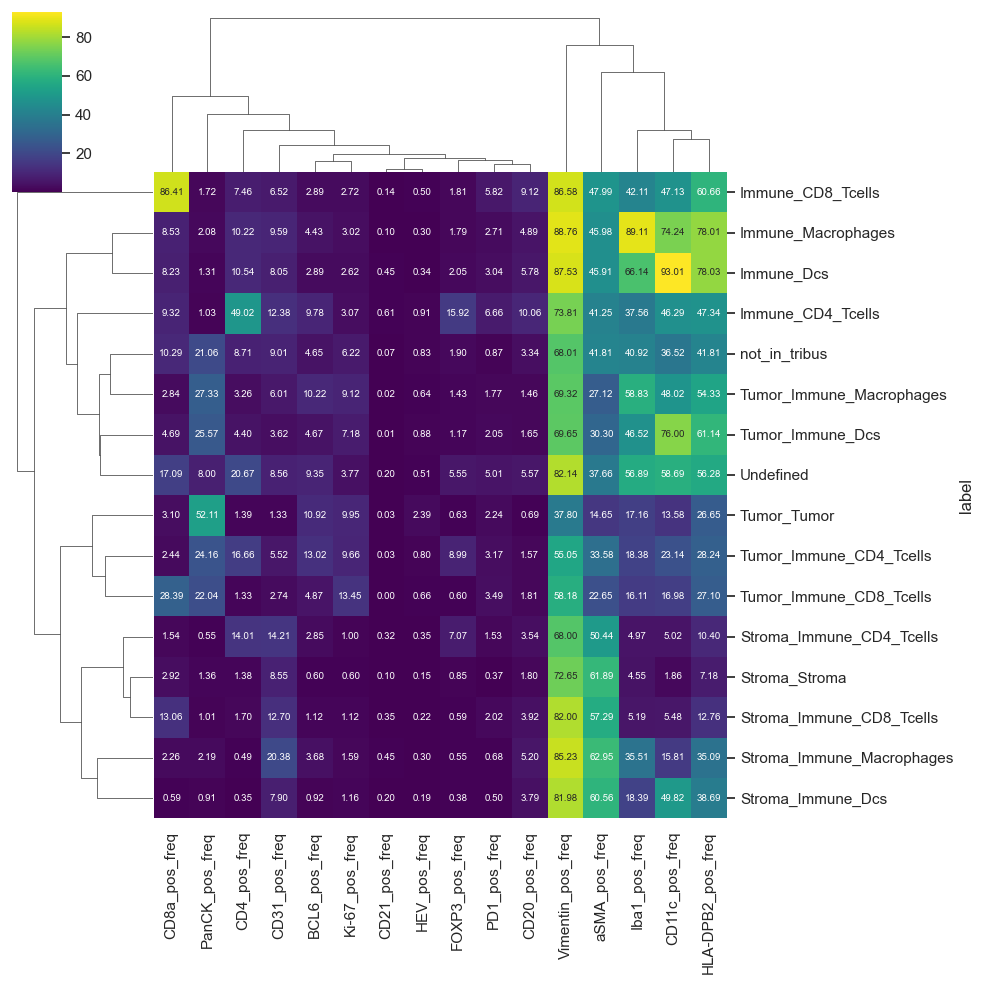

In [99]:
# Calculate overall marker frequencies
freq_df = marker_frequency_by_label(df, markers)
freq_df = freq_df.sort_values('n_cells', ascending=False)
freq_df = freq_df.set_index("label")
sns.clustermap(freq_df[['BCL6_pos_freq', 'FOXP3_pos_freq', 'PD1_pos_freq',
       'CD21_pos_freq', 'Ki-67_pos_freq', 'CD20_pos_freq', 'Vimentin_pos_freq',
       'CD4_pos_freq', 'CD11c_pos_freq', 'CD8a_pos_freq', 'HEV_pos_freq',
       'PanCK_pos_freq', 'CD31_pos_freq', 'Iba1_pos_freq', 'aSMA_pos_freq',
       'HLA-DPB2_pos_freq']], annot=True, fmt=".2f", cmap='viridis',annot_kws={"size": 7})

In [ ]:
# Refine labels

# 1. Clean the original labels first to avoid whitespace issues
df['final_label_tribus'] = df['final_label_tribus'].astype(str).str.strip()

# 2. Define the "failed marker" conditions
failed_check = (
    ((df['final_label_tribus'].str.contains('CD4', na=False)) & (df['CD4'] == False)) |
    ((df['final_label_tribus'].str.contains('CD8', na=False)) & (df['CD8a'] == False)) |
    ((df['final_label_tribus'].str.contains('Macrophage', na=False)) & (df['Iba1'] == False)) |
    ((df['final_label_tribus'].str.contains('Dcs', na=False)) & (df['CD11c'] == False))
)

# 3. Fallback logic function
def get_fallback_label(label):
    if 'Stroma' in str(label):
        return 'Stroma_Stroma'
    elif 'Tumor' in str(label):
        return 'Tumor_Tumor'
    else:
        return 'Stroma_Stroma'

# 4. Create consensus (Handling the "Fake" removal)
df['consensus'] = np.where(
    failed_check,
    df['final_label_tribus'].apply(get_fallback_label),
    df['final_label_tribus']
)

# 5. NEW CONDITION: If it's Tumor_Tumor but CD8+, relabel to Tumor_Immune_CD8_Tcells
# We do this AFTER the step above to catch cells that were always Tumor or were just moved there
tumor_cd8_mask = (df['consensus'] == 'Tumor_Tumor') & (df['CD8a'] == True)
df['consensus'] = np.where(tumor_cd8_mask, 'Tumor_Immune_CD8_Tcells', df['consensus'])

# 6. Create Simplified column and strip spaces
df['consensus'] = df['consensus'].astype(str).str.strip()
def simplify_label(label):
    label = str(label).strip()
    # Match pattern: find things like CD8_Tcells or CD4_Tcells at the end
    match = re.search(r'([A-Za-z0-9]+_Tcells)$', label)
    if match:
        return match.group(1)
    # Fallback: if not a Tcell, just take the last part after the last underscore
    return label.split('_')[-1]
df['consensus_simplified'] = df['consensus'].apply(simplify_label)

# 7. Convert to categories
df['consensus'] = df['consensus'].astype('category')
df['consensus_simplified'] = df['consensus_simplified'].astype('category')

In [ ]:
def relabel_with_hierarchy(row):
    label = str(row['consensus_simplified']).strip()
    
    # Define the specific populations to check
    target_cells = ['Tumor', 'Stroma', 'Macrophages', 'DCs', 'CD4_Tcells', 'CD8_Tcells']
    
    if label in target_cells:
        # 1. First check: CD31 (Highest Priority)
        if row['CD31'] == True:
            return 'CD31+_Endothelial'
        
        # 2. Second check: HEV
        if row['HEV'] == True:
            return 'HEV+_Endothelial'
            
        # 3. Third check: CD20
        if row['CD20'] == True:
            if label == 'CD8_Tcells':
                return 'CD8_Tcells'
            elif label == 'CD4_Tcells':
                return 'Bcells'
            else:
                return 'Bcells' # For Tumor, Stroma, Macrophages, DCs
                
    return label

# Apply the hierarchical relabeling
df['consensus_simplified'] = df.apply(relabel_with_hierarchy, axis=1)
df['consensus_simplified'] = df['consensus_simplified'].astype('category')

label_map = {
    "CD31+": "CD31_Endothelial",
    "HEV+": "HEV_Endothelial",
    "Dcs": "DCs",
    "B cells": "B_cells"
}

# Apply the replacement to the specific column
df["consensus_simplified"] = df["consensus_simplified"].replace(label_map)

C:\Users\Localadmin_junqmada\AppData\Local\Temp\ipykernel_21964\219908497.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



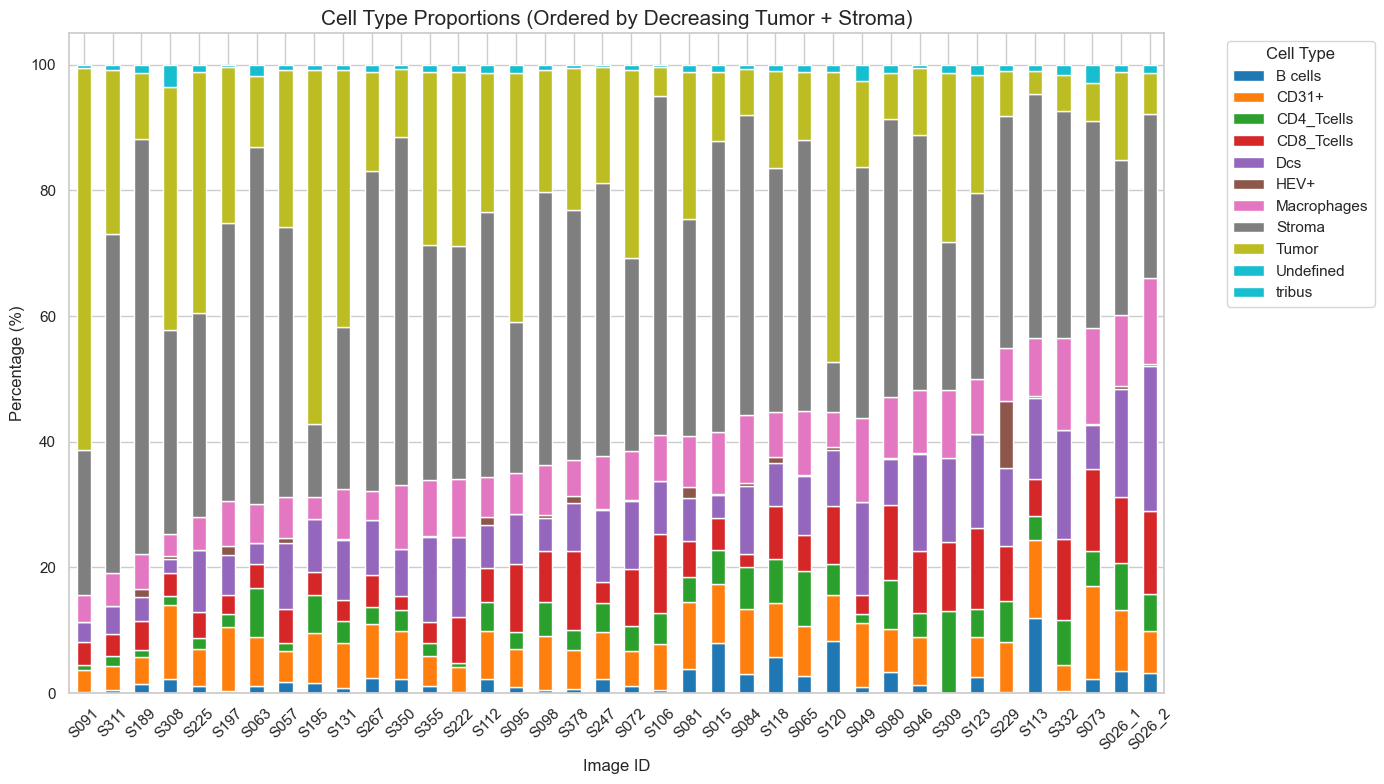

In [134]:
# Sample statistics
#  We only keep rows where simplified label is NOT 'tribus'
plot_df = df[df['consensus_simplified'] != 'tribus'].copy()

# Create a frequency table (counts) then convert to percentages (proportions)
counts = plot_df.groupby(['imageid', 'consensus_simplified']).size().unstack(fill_value=0)
proportions = counts.div(counts.sum(axis=1), axis=0) * 100

# 1. Calculate the sum of Tumor and Stroma for sorting
# We check if both columns exist to avoid errors
sort_cols = [c for c in ['Tumor', 'Stroma'] if c in proportions.columns]
proportions['total_structural'] = proportions[sort_cols].sum(axis=1)

# 2. Sort the dataframe by this sum in descending order
proportions_sorted = proportions.sort_values(by='total_structural', ascending=False)

# 3. Drop the temporary sorting column so it doesn't appear in the plot
plot_data = proportions_sorted.drop(columns=['total_structural'])

# 4. Plot the stacked bar chart
ax = plot_data.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab10')

# Formatting
plt.title('Cell Type Proportions (Ordered by Decreasing Tumor + Stroma)', fontsize=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Image ID', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Visualize

In [135]:
target_id = "S229"
subset = df[df['imageid'] == target_id].copy()

# 3. Define marker columns
marker_cols = [
    'BCL6', 'CD138', 'Tcf1', 'FOXP3', 'PD1', 'CD21', 'Ki-67', 'CD20', 
    'Vimentin', 'CD4', 'CD11c', 'CD8a', 'HEV', 'PanCK', 'CD31', 
    'Iba1', 'CD3D', 'IgD', 'aSMA', 'HLA-DPB2', 'HLA-A'
]

# 4. Create the AnnData object with X as all zeros
adata = ad.AnnData(
    X=np.zeros((subset.shape[0], len(marker_cols))),
    obs=subset[['imageid', 'X_centroid', 'Y_centroid', 'consensus','consensus_simplified']].rename(columns={'sample_name': 'sample'}),
    var=pd.DataFrame(index=marker_cols)
)

adata.obs['consensus'] = adata.obs['consensus'].astype('category')
adata.obs['consensus_simplified'] = adata.obs['consensus_simplified'].astype('category')

c:\Users\Localadmin_junqmada\.conda\envs\scimap\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [ ]:
import scimap as sm

directory_img = 'F://farkkilab2//7_TLS//Data//Exp_4//tif//'
file_image_dir = directory_img +"7-S229_iOme_01254_4A.ome.tif"

marker_list_with_DNA = ['DAPI1', 'BCL6', 'IgG', 'AICDA', 'CD138', 'DAPI2', 'Tcf1',
       'FOXP3', 'PD1', 'CD45', 'DAPI3', 'CD21', 'Ki-67', 'CD20', 'Vimentin',
       'DAPI4', 'CD4', 'CD11c', 'CD8a', 'DAPI5', 'HEV', 'PanCK', 'CD31',
       'DAPI6', 'Iba1', 'CD3D', 'IgD', 'DAPI7', 'aSMA', 'HLA-DPB2', 'HLA-A','DAPI8', 'CD68', 'PAX8', 'NKG2A', 'DAPI9', 'CD163', 'FAP', 'PAX8_2']#,

sm.pl.image_viewer(file_image_dir, adata, overlay = 'consensus_simplified', channel_names = marker_list_with_DNA,x_coordinate="X_centroid",y_coordinate="Y_centroid", point_size=5)

In [ ]:
#Export
df[['CellID', 'imageid', 'X_centroid',
       'Y_centroid', 'BCL6', 'CD138', 'Tcf1', 'FOXP3', 'PD1', 'CD21', 'Ki-67',
       'CD20', 'Vimentin', 'CD4', 'CD11c', 'CD8a', 'HEV', 'PanCK', 'CD31',
       'Iba1', 'CD3D', 'IgD', 'aSMA', 'HLA-DPB2', 'HLA-A', 'labels',
       'labels_less', 'labels_less_freq', 'final_label_tribus', 'consensus',
       'consensus_simplified']].to_csv("F://farkkilab2//7_TLS/Data/Exp_4/cell-phenotyping/20260210_consensus_labels.csv")